# ACN 데이터 탐색 (대용량 처리)

| 파일 | 크기 |
|------|------|
| acn_all_sites.csv | ~80GB |
| caltech.csv | ~36GB |
| jpl.csv | ~42GB |
| office001.csv | ~2.1GB |

**전략**: Polars `scan_csv` (Lazy API) 사용 → 실제로 필요한 연산만 메모리에 로드

## 0. 환경 확인 및 설정

In [2]:
import subprocess, sys

# 필요한 패키지 확인 / 설치
required = ['polars', 'matplotlib', 'tqdm']
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import polars as pl
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path

matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

print(f'Polars version: {pl.__version__}')

DATA_DIR = Path(r'c:\Users\haiwon\Desktop\이산 최적화\acn_data')
FILES = {
    'office001': DATA_DIR / 'office001.csv',  # 2.1GB  ← 탐색 시작
    'caltech':   DATA_DIR / 'caltech.csv',    # 36GB
    'jpl':       DATA_DIR / 'jpl.csv',        # 42GB
    'all_sites': DATA_DIR / 'acn_all_sites.csv',  # 80GB
}

for name, path in FILES.items():
    size_gb = path.stat().st_size / 1e9
    print(f'  {name:12s}: {size_gb:.1f} GB')

Polars version: 1.39.2
  office001   : 2.2 GB
  caltech     : 38.6 GB
  jpl         : 45.0 GB
  all_sites   : 85.8 GB


## 1. 스키마 확인 (컬럼명 & 타입)
Lazy scan은 파일을 실제로 읽지 않고 메타데이터만 파악합니다.

In [3]:
# 가장 작은 office001로 스키마 확인
TARGET = 'office001'  # ← 변경해서 다른 파일 탐색 가능

lf = pl.scan_csv(
    FILES[TARGET],
    ignore_errors=True,   # 파싱 오류 행 스킵
    infer_schema_length=100,
)

print(f'=== {TARGET} 스키마 ===')
for col, dtype in lf.schema.items():
    print(f'  {col:<25} {dtype}')

=== office001 스키마 ===
  _id                       String
  userInputs                String
  userID                    String
  sessionID                 String
  stationID                 String
  spaceID                   Int64
  siteID                    Int64
  clusterID                 Int64
  connectionTime            String
  disconnectTime            String
  kWhDelivered              Float64
  pilotSignal               String
  chargingCurrent           String
  doneChargingTime          String
  timezone                  String


C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\2972498685.py:11: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  for col, dtype in lf.schema.items():


## 2. 상위 5행 미리보기

In [4]:
# pilotSignal / chargingCurrent 컬럼은 매우 긴 직렬화 문자열이므로 제외
EXCLUDE_COLS = ['pilotSignal', 'chargingCurrent', 'userInputs']

simple_cols = [c for c in lf.columns if c not in EXCLUDE_COLS]

preview = lf.select(simple_cols).head(5).collect()
display(preview)

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\1308796027.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  simple_cols = [c for c in lf.columns if c not in EXCLUDE_COLS]


_id,userID,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone
str,str,str,str,i64,i64,i64,str,str,f64,str,str
"""5cd1d47af9af8b68f0e96713""",null,"""19_102_260_1633_2019-03-25 16:…","""19-102-260-1633""",2,19,102,"""2019-03-25 16:24:42+00:00""","""2019-03-26 01:32:12+00:00""",6.146,"""2019-03-25 17:32:48+00:00""","""America/Los_Angeles"""
"""5cd1d47af9af8b68f0e96714""",null,"""19_102_260_1634_2019-03-25 17:…","""19-102-260-1634""",3,19,102,"""2019-03-25 17:19:27+00:00""","""2019-03-26 00:38:50+00:00""",3.658,"""2019-03-25 18:00:49+00:00""","""America/Los_Angeles"""
"""5cd1d47af9af8b68f0e96715""",null,"""19_102_260_1640_2019-03-25 21:…","""19-102-260-1640""",8,19,102,"""2019-03-25 21:27:32+00:00""","""2019-03-26 03:32:03+00:00""",28.33,"""2019-03-26 02:10:40+00:00""","""America/Los_Angeles"""
"""5cd1d47df9af8b68f0e96716""",null,"""19_102_260_1640_2019-03-26 18:…","""19-102-260-1640""",8,19,102,"""2019-03-26 18:33:56+00:00""","""2019-03-27 00:45:33+00:00""",12.978,"""2019-03-26 22:30:58+00:00""","""America/Los_Angeles"""
"""5cd1d47ef9af8b68f0e96717""",null,"""19_102_260_1640_2019-03-27 18:…","""19-102-260-1640""",8,19,102,"""2019-03-27 18:28:01+00:00""","""2019-03-28 00:37:47+00:00""",10.688,"""2019-03-27 21:44:03+00:00""","""America/Los_Angeles"""


## 3. 전체 행 수 & 사이트/스테이션 현황

In [5]:
# collect()를 호출하는 시점에만 실제 파일을 읽음
row_count = lf.select(pl.len()).collect().item()
print(f'총 행 수: {row_count:,}')

# siteID / clusterID 분포
if 'siteID' in lf.columns:
    site_dist = (
        lf.select(['siteID', 'clusterID'])
          .group_by(['siteID', 'clusterID'])
          .agg(pl.len().alias('count'))
          .sort('count', descending=True)
          .collect()
    )
    display(site_dist)

총 행 수: 1,683


C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\2936511953.py:6: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'siteID' in lf.columns:


siteID,clusterID,count
i64,i64,u32
19,102,1683


## 4. 핵심 수치 컬럼 기초 통계

In [6]:
numeric_cols = ['kWhDelivered']
existing = [c for c in numeric_cols if c in lf.columns]

if existing:
    stats = (
        lf.select(existing)
          .cast({c: pl.Float64 for c in existing}, strict=False)
          .select([
              pl.col(c).mean().alias(f'{c}_mean') for c in existing
          ] + [
              pl.col(c).std().alias(f'{c}_std') for c in existing
          ] + [
              pl.col(c).min().alias(f'{c}_min') for c in existing
          ] + [
              pl.col(c).max().alias(f'{c}_max') for c in existing
          ] + [
              pl.col(c).median().alias(f'{c}_median') for c in existing
          ])
          .collect()
    )
    display(stats)

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\1535647870.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  existing = [c for c in numeric_cols if c in lf.columns]


kWhDelivered_mean,kWhDelivered_std,kWhDelivered_min,kWhDelivered_max,kWhDelivered_median
f64,f64,f64,f64,f64
17.274058,12.006225,0.52,65.217,14.755


## 5. 시간 범위 확인 (connectionTime)

In [7]:
if 'connectionTime' in lf.columns:
    time_stats = (
        lf.select(
            pl.col('connectionTime').min().alias('earliest'),
            pl.col('connectionTime').max().alias('latest'),
        ).collect()
    )
    print('최초 세션:', time_stats['earliest'][0])
    print('최근 세션:', time_stats['latest'][0])

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\1772893550.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'connectionTime' in lf.columns:


최초 세션: 2019-03-25 16:24:42+00:00
최근 세션: 2021-09-13 21:21:51+00:00


## 6. kWhDelivered 히스토그램

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\3338134650.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'kWhDelivered' in lf.columns:


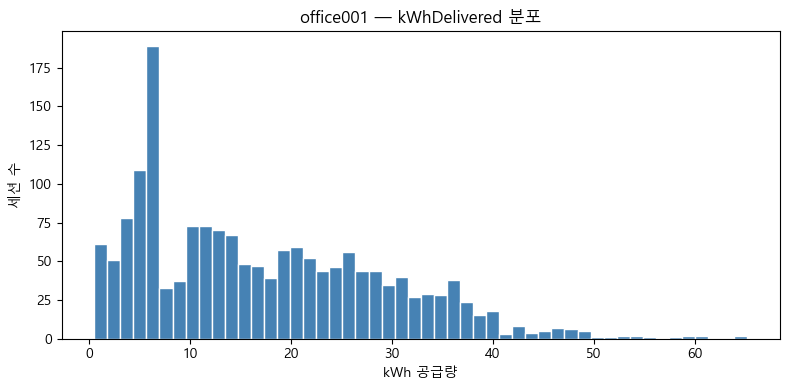

총 1,683개 세션, 합계 29,072.2 kWh


In [8]:
if 'kWhDelivered' in lf.columns:
    kwh_series = (
        lf.select(pl.col('kWhDelivered').cast(pl.Float64, strict=False).drop_nulls())
          .collect()
          ['kWhDelivered']
          .to_list()
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(kwh_series, bins=50, color='steelblue', edgecolor='white')
    ax.set_xlabel('kWh 공급량')
    ax.set_ylabel('세션 수')
    ax.set_title(f'{TARGET} — kWhDelivered 분포')
    plt.tight_layout()
    plt.show()

    print(f'총 {len(kwh_series):,}개 세션, 합계 {sum(kwh_series):,.1f} kWh')

## 7. 월별 세션 수 추이

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\951059151.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'connectionTime' in lf.columns:


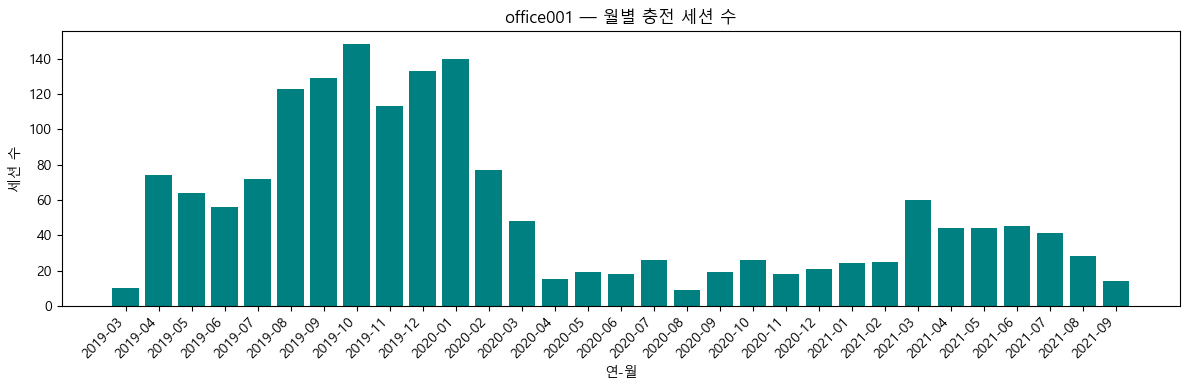

In [9]:
if 'connectionTime' in lf.columns:
    monthly = (
        lf.select('connectionTime')
          .with_columns(
              pl.col('connectionTime').str.slice(0, 7).alias('ym')  # 'YYYY-MM'
          )
          .group_by('ym')
          .agg(pl.len().alias('sessions'))
          .sort('ym')
          .collect()
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(monthly['ym'].to_list(), monthly['sessions'].to_list(), color='teal')
    ax.set_xlabel('연-월')
    ax.set_ylabel('세션 수')
    ax.set_title(f'{TARGET} — 월별 충전 세션 수')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. 충전 시간 분석 (connectionTime → disconnectTime)

C:\Users\haiwon\AppData\Local\Temp\ipykernel_220516\3777825116.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'connectionTime' in lf.columns and 'disconnectTime' in lf.columns:


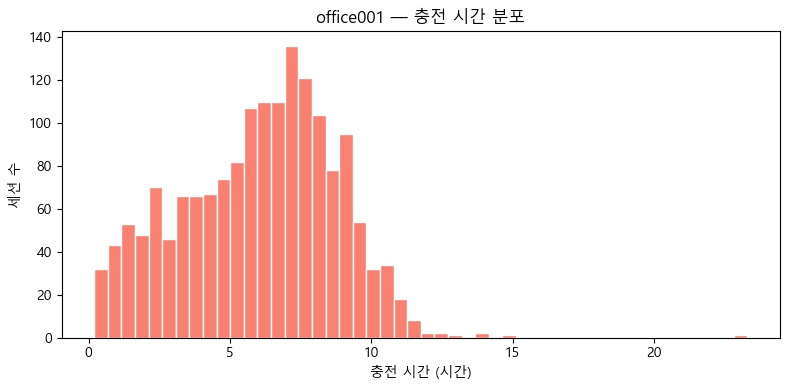

평균 충전시간: 6.0시간
중앙값: 6.3시간


In [10]:
if 'connectionTime' in lf.columns and 'disconnectTime' in lf.columns:
    duration_df = (
        lf.select(['connectionTime', 'disconnectTime', 'kWhDelivered'])
          .with_columns([
              pl.col('connectionTime').str.replace(r'\+.*$', '').str.to_datetime('%Y-%m-%d %H:%M:%S', strict=False),
              pl.col('disconnectTime').str.replace(r'\+.*$', '').str.to_datetime('%Y-%m-%d %H:%M:%S', strict=False),
          ])
          .with_columns(
              ((pl.col('disconnectTime') - pl.col('connectionTime')).dt.total_minutes()).alias('duration_min')
          )
          .select(['duration_min', 'kWhDelivered'])
          .filter(pl.col('duration_min') > 0)
          .collect()
    )

    durations = duration_df['duration_min'].drop_nulls().to_list()
    hours = [d / 60 for d in durations if d < 24 * 60]  # 24시간 이하만

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(hours, bins=48, color='salmon', edgecolor='white')
    ax.set_xlabel('충전 시간 (시간)')
    ax.set_ylabel('세션 수')
    ax.set_title(f'{TARGET} — 충전 시간 분포')
    plt.tight_layout()
    plt.show()

    import statistics
    print(f'평균 충전시간: {statistics.mean(hours):.1f}시간')
    print(f'중앙값: {statistics.median(hours):.1f}시간')

## 9. 청킹으로 대용량 파일 순차 처리 (caltech / jpl용)
> 메모리를 초과하는 파일을 청크 단위로 처리하는 패턴

In [ ]:
# 예시: caltech.csv에서 kWhDelivered 합계만 청킹으로 계산
# (실행하려면 TARGET을 'caltech' 등으로 변경)

CHUNK_TARGET = 'office001'  # ← 'caltech' / 'jpl' 로 변경 가능
CHUNK_ROWS   = 5_000        # 한 번에 읽을 행 수

total_kwh = 0.0
total_rows = 0

reader = pl.read_csv_batched(
    FILES[CHUNK_TARGET],
    batch_size=CHUNK_ROWS,
    columns=['kWhDelivered'],
    ignore_errors=True,
)

while True:
    batch = reader.next_batches(1)
    if not batch:
        break
    df_batch = batch[0].cast({'kWhDelivered': pl.Float64}, strict=False)
    total_kwh  += df_batch['kWhDelivered'].drop_nulls().sum()
    total_rows += len(df_batch)

print(f'{CHUNK_TARGET}: 총 {total_rows:,}행, 합계 {total_kwh:,.1f} kWh')

## 10. 누락값 현황

In [ ]:
null_counts = (
    lf.select(simple_cols)
      .select([pl.col(c).is_null().sum().alias(c) for c in simple_cols])
      .collect()
)

null_dict = {col: null_counts[col][0] for col in null_counts.columns}
null_df = pl.DataFrame({'column': list(null_dict.keys()), 'null_count': list(null_dict.values())})
null_df = null_df.with_columns(
    (pl.col('null_count') / row_count * 100).round(2).alias('null_%')
).sort('null_count', descending=True)

display(null_df)